Dict{Symbol, Any}(:T => 24, :dispatchableGenerators => Dict{Any, Any}("Base" => Dict{Any, Any}("bidPrice" => 30, "capacity" => 1500), "Peak" => Dict{Any, Any}("bidPrice" => 100, "capacity" => 700)), :demandSegments => Dict{Any, Any}("Base" => Dict{Any, Any}("bidPrice" => 300, "quantity" => [1500, 1500, 1500, 1600, 1800, 1900, 2300, 2500, 2200, 2200, 2300, 2200, 2100, 2200, 2200, 2200, 2400, 2500, 2600, 2500, 2200, 2100, 1900, 1700]), "Flex" => Dict{Any, Any}("bidPrice" => 50, "quantity" => [200, 200, 200, 200, 200, 300, 400, 500, 500, 500, 500, 500, 500, 500, 400, 300, 300, 300, 300, 300, 300, 300, 300, 300])), :variableGenerators => Dict{Any, Any}("Wind" => Dict{Any, Any}("profile" => [0.2, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5, 0.6, 0.4, 0.35, 0.3, 0.3, 0.25, 0.25, 0.2, 0.2, 0.7, 0.8, 0.85, 0.8, 0.75, 0.7, 0.6, 0.5], "bidPrice" => 0, "capacity" => 1000), "Solar" => Dict{Any, Any}("profile" => [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1, 0.2, 0.35, 0.5, 0.6, 0.75, 0.85, 0.9, 0.8, 0.7, 0.5, 0.25,

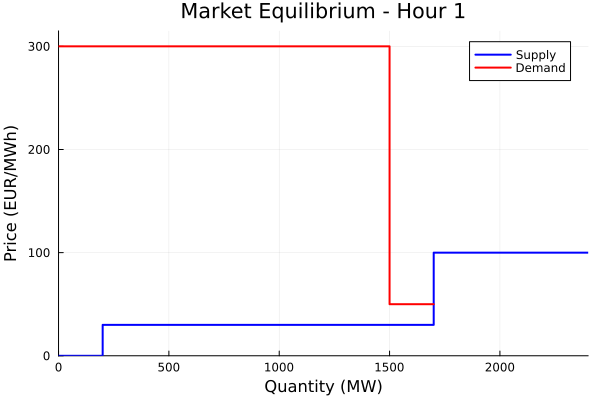

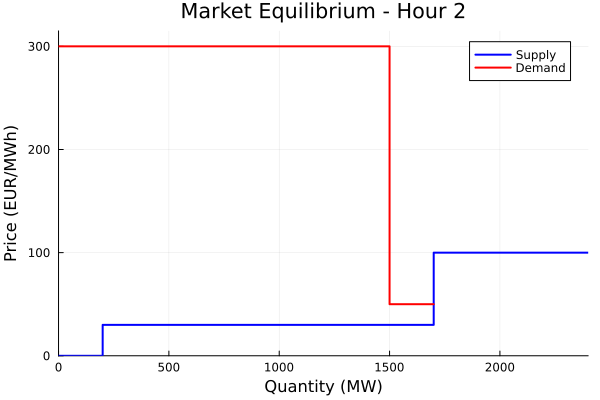

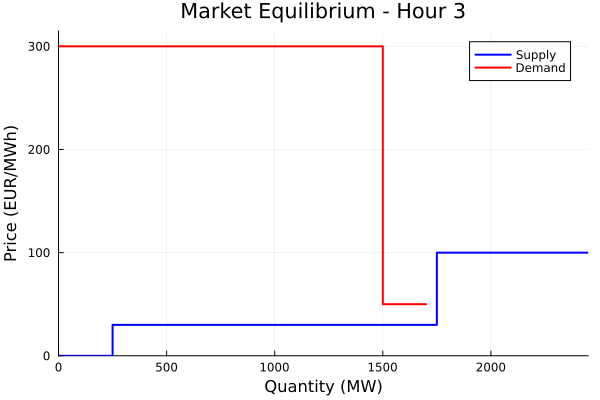

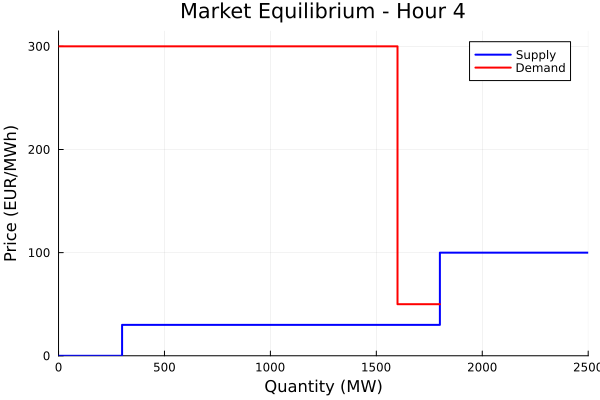

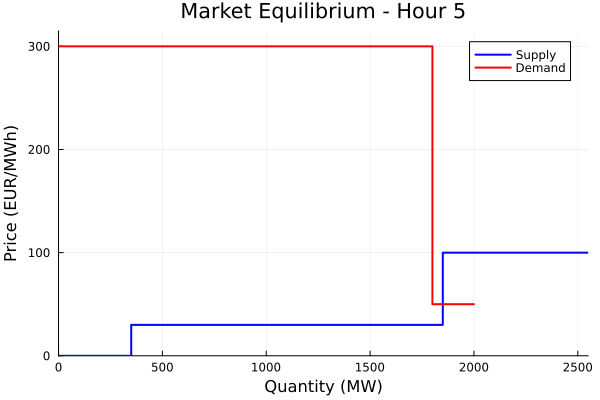

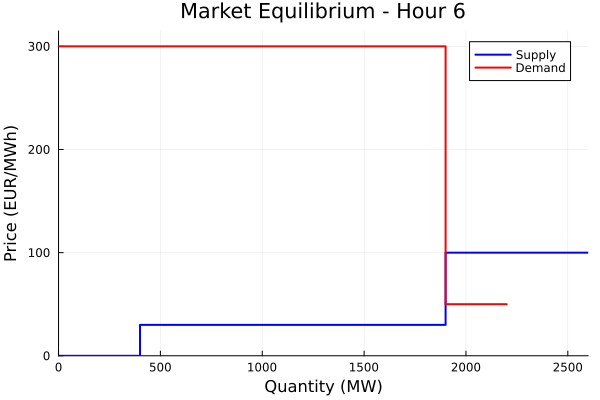

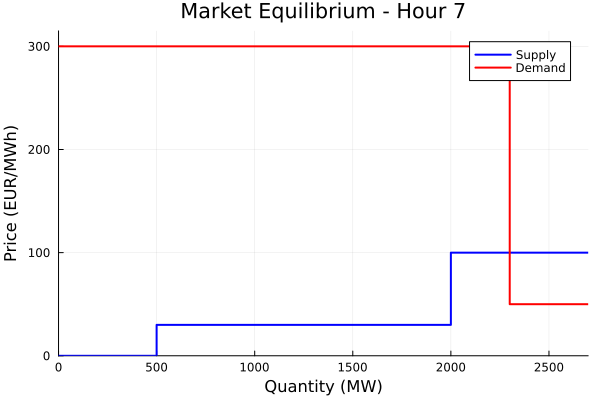

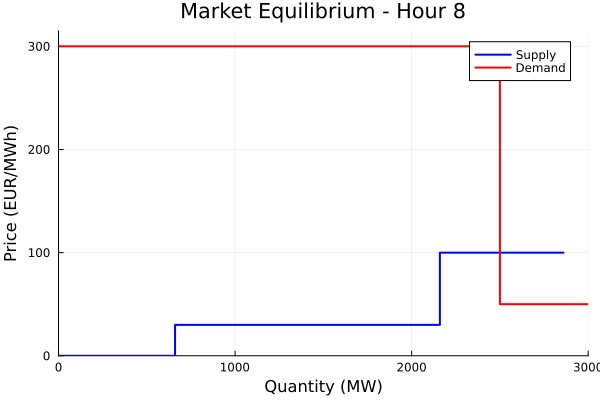

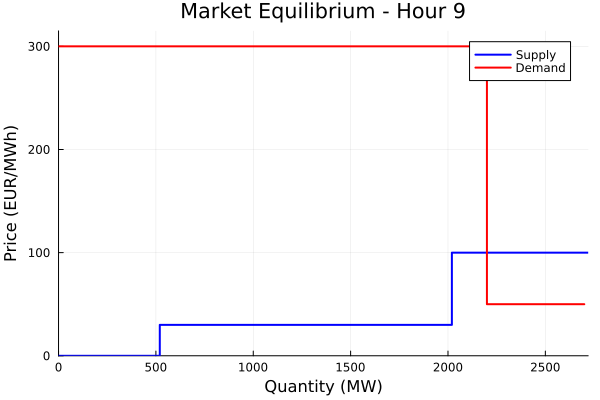

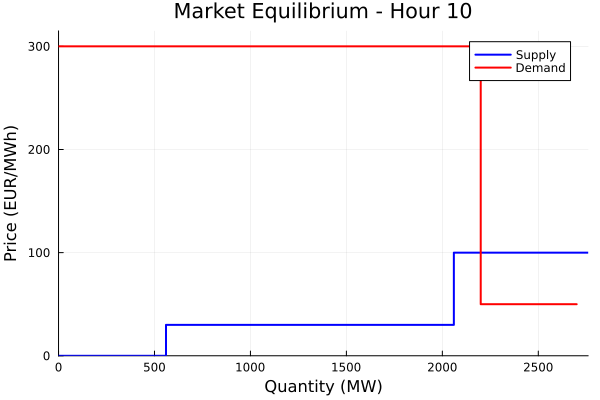

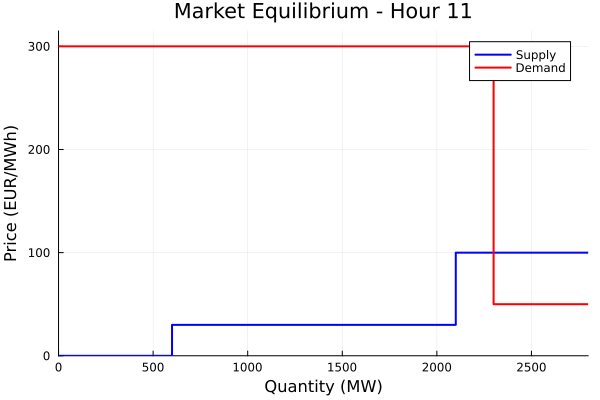

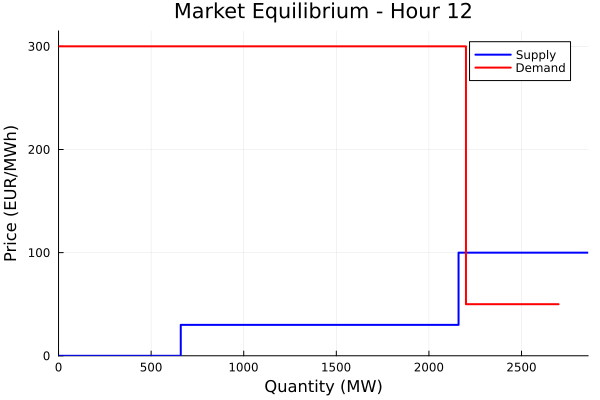

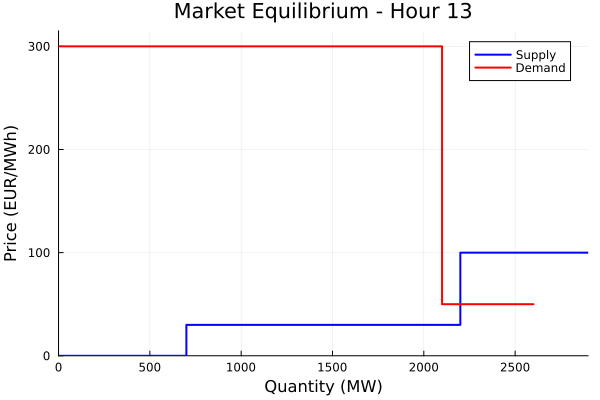

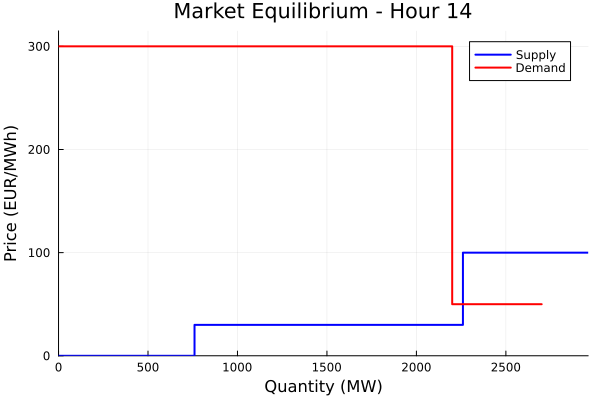

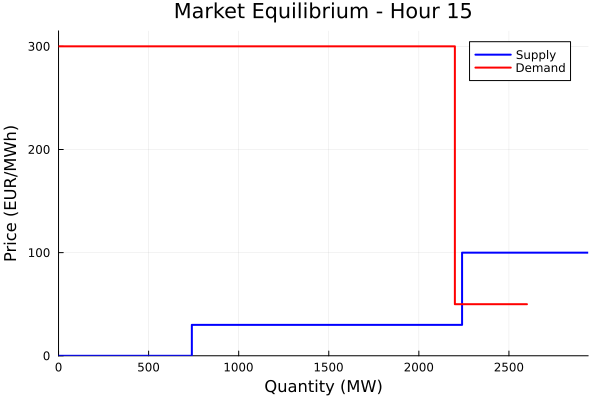

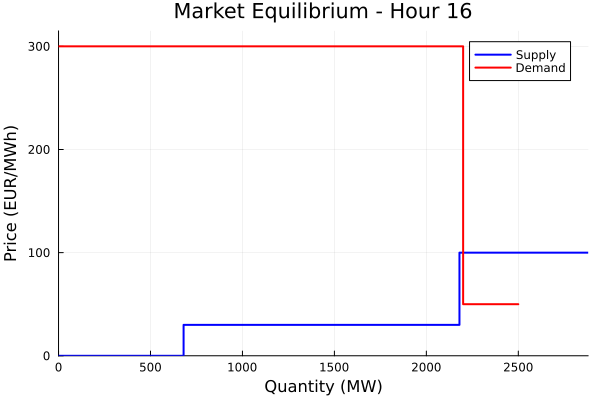

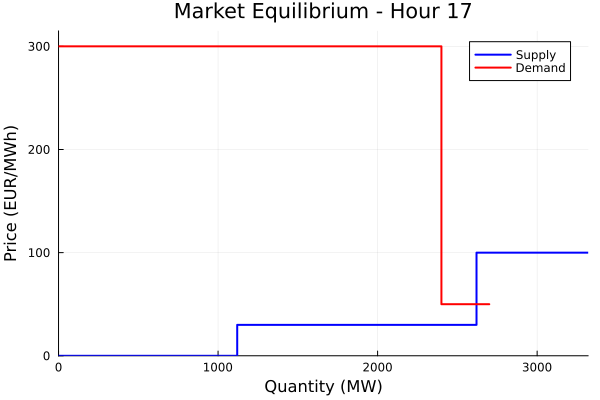

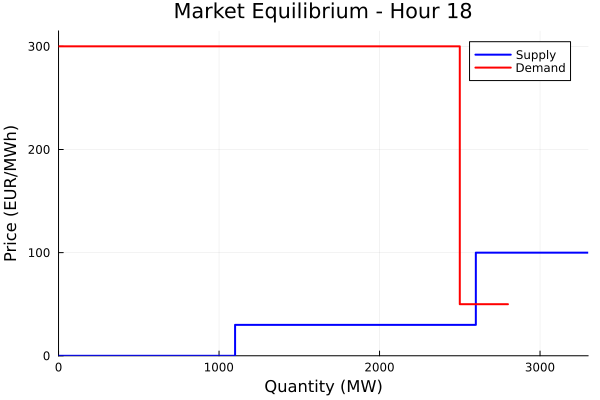

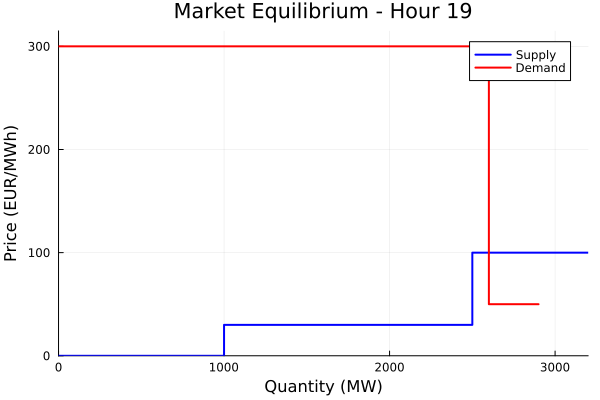

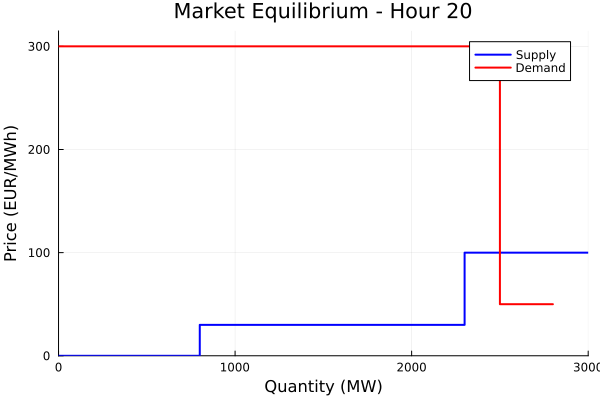

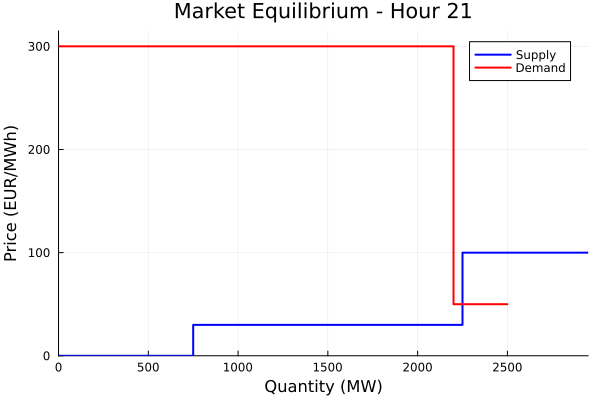

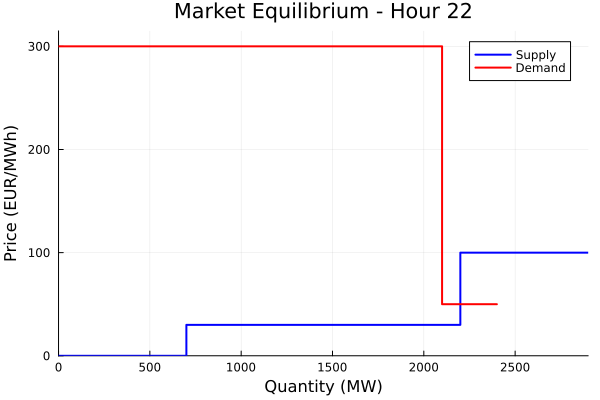

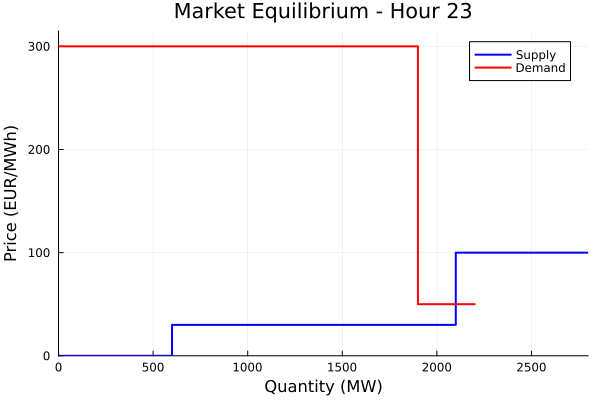

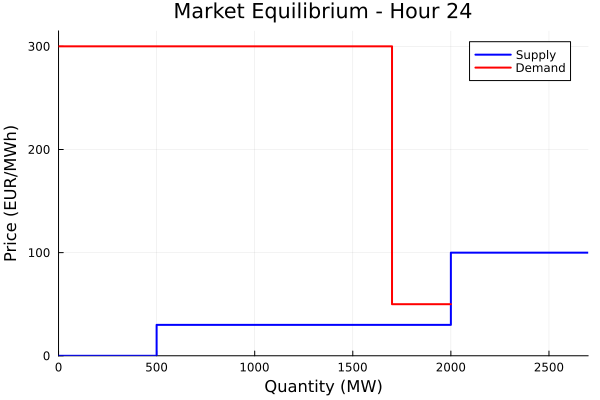

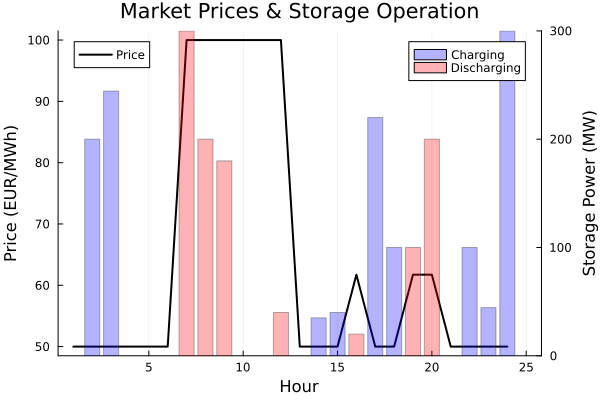

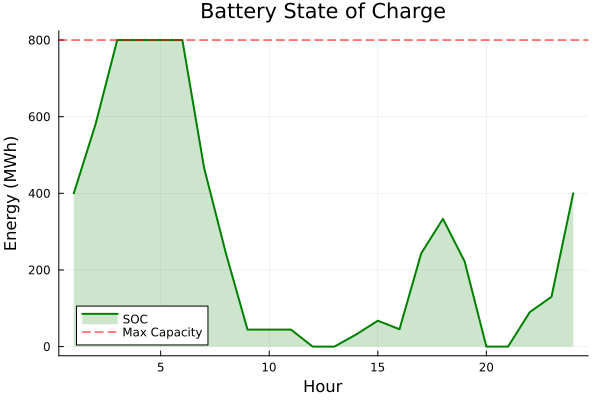

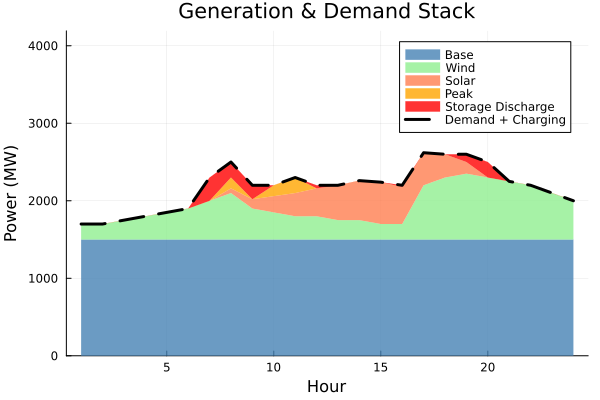

done


In [19]:
using JuMP

include("lib\\data_importer.jl")
include("lib\\build_model.jl")
include("lib\\plots\\plot_hourly_market_equilibrium.jl")
include("lib\\plots\\plot_market_prices_with_storage.jl")
include("lib\\plots\\plot_state_of_charge.jl")
include("lib\\plots\\plot_generation_stack.jl")

data = DataImporter.load_input_data("simple_market_clearing\\input_data.yaml")
println(data)
m = BuildModel.build(data)
# println(m)
optimize!(m)
println("Termination status: ", termination_status(m))
println("Objective value: ", objective_value(m))

# next up, plot some things
# could this be configurable based on yaml input?


# these display themselves, should they??

for iter in m.ext[:sets][:JH]
    PlotHourlyMarketEquilibrium.plot(m,iter)
end
PlotMarketPricesWithStorage.plot(m)
PlotStateOfCharge.plot(m)
PlotGenerationStack.plot(m)


println("done")


In [ ]:
|